**Step 1 - Import the libraries**

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
RANDOM_STATE = 42

**Step 2 - Load Data**

In [78]:
df = pd.read_csv("fraud_oracle.csv")

print("=" * 40)
print("           DATASET OVERVIEW")
print("=" * 40)
print(f"  Total claims   : {df.shape[0]:,}")
print(f"  Total columns  : {df.shape[1]}")
print(f"  Fraud cases    : {df['FraudFound_P'].sum():,}")
print(f"  Genuine cases  : {(df['FraudFound_P']==0).sum():,}")
print(f"  Fraud rate     : {df['FraudFound_P'].mean():.2%}")
print("=" * 40)

           DATASET OVERVIEW
  Total claims   : 15,420
  Total columns  : 33
  Fraud cases    : 923
  Genuine cases  : 14,497
  Fraud rate     : 5.99%


**Step 3 - Clean Data and Defining Columns**

In [79]:
TARGET = 'FraudFound_P'
DROP = ['PolicyNumber', 'RepNumber']          # identifiers, not predictors

df = df.drop(columns=DROP)
df['Age'] = df['Age'].replace(0, np.nan)      # 0 actually means "unknown"

#Define Columns
numeric = [c for c in df.select_dtypes('number').columns if c != TARGET]
categorical = [c for c in df.columns if c not in numeric + [TARGET]]
X = df[numeric + categorical]
y = df[TARGET]

**Step 4 - EDA**

(a) Class balance

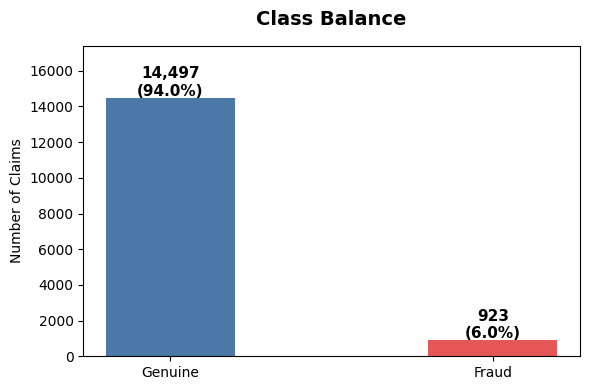

In [80]:
counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Genuine', 'Fraud'], counts.values,
               color=['#4C78A8', '#E45756'], width=0.4)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{val:,}\n({val/len(y):.1%})",
             ha='center', fontsize=11, fontweight='bold')
plt.title('Class Balance', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Claims')
plt.ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.show()

(b) Fraud rate by category

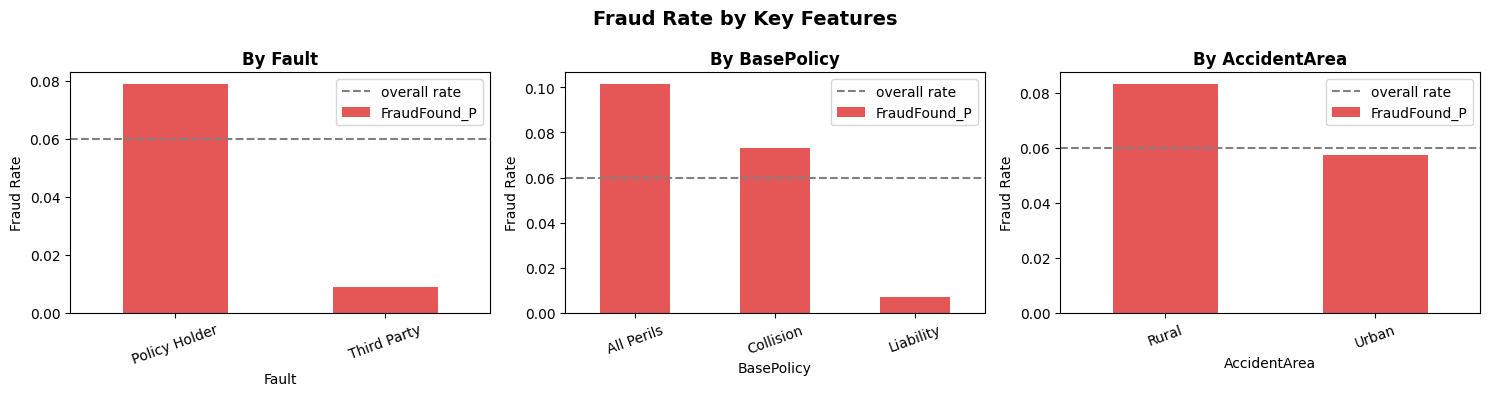

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Fraud Rate by Key Features', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['Fault', 'BasePolicy', 'AccidentArea']):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#E45756')
    ax.axhline(y.mean(), ls='--', color='grey', label='overall rate')
    ax.set_title(f'By {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=20)
    ax.legend()

plt.tight_layout()
plt.show()

**Step 5 - Train/test split**

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print("=" * 45)
print("         TRAIN / TEST SPLIT")
print("=" * 45)
print(f"  Training rows  : {len(X_train):,}")
print(f"  Test rows      : {len(X_test):,}")
print(f"  Train fraud %  : {y_train.mean():.2%}")
print(f"  Test fraud %   : {y_test.mean():.2%}")
print(f"  No-skill baseline (PR-AUC) : {y_test.mean():.3f}")
print("=" * 45)

         TRAIN / TEST SPLIT
  Training rows  : 11,565
  Test rows      : 3,855
  Train fraud %  : 5.98%
  Test fraud %   : 5.99%
  No-skill baseline (PR-AUC) : 0.060


**Step 6 - Preprocessing Pipeline (leakage-safe)**

In [83]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
])

**Step 7 - Baseline: Logistic Regression**

In [84]:
logreg = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_auc = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='roc_auc')


print("=" * 45)
print("       LOGISTIC REGRESSION (CV)")
print("=" * 45)
print(f"  Fold scores : {[round(s, 3) for s in lr_auc]}")
print(f"  Mean AUC    : {lr_auc.mean():.3f}")
print(f"  Std dev     : {lr_auc.std():.3f}")
print("=" * 45)

       LOGISTIC REGRESSION (CV)
  Fold scores : [np.float64(0.803), np.float64(0.818), np.float64(0.813), np.float64(0.785), np.float64(0.805)]
  Mean AUC    : 0.805
  Std dev     : 0.011


**Step 8 - Random Forest**

In [85]:
rf = Pipeline([
    ('prep', preprocess),
    ('clf',  RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                    class_weight='balanced_subsample',
                                    n_jobs=-1, random_state=RANDOM_STATE)),
])

rf_auc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print("=" * 45)
print("         RANDOM FOREST (CV)")
print("=" * 45)
print(f"  Fold scores : {[round(s, 3) for s in rf_auc]}")
print(f"  Mean AUC    : {rf_auc.mean():.3f}")
print(f"  Std dev     : {rf_auc.std():.3f}")
print("-" * 45)
print(f"  Logistic Regression : {lr_auc.mean():.3f}")
print(f"  Random Forest       : {rf_auc.mean():.3f}")
print("-" * 45)
winner     = 'Random Forest' if rf_auc.mean() >= lr_auc.mean() else 'Logistic Regression'
best_model = rf             if rf_auc.mean() >= lr_auc.mean() else logreg
print(f"  Winner : {winner}")
print("=" * 45)

         RANDOM FOREST (CV)
  Fold scores : [np.float64(0.82), np.float64(0.855), np.float64(0.849), np.float64(0.789), np.float64(0.84)]
  Mean AUC    : 0.831
  Std dev     : 0.024
---------------------------------------------
  Logistic Regression : 0.805
  Random Forest       : 0.831
---------------------------------------------
  Winner : Random Forest


**Step 9 - Evaluate on the held-out test set**

In [86]:
best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]

roc  = roc_auc_score(y_test, proba)
pr   = average_precision_score(y_test, proba)
base = y_test.mean()

print("=" * 45)
print("      MODEL PERFORMANCE (TEST SET)")
print("=" * 45)
print(f"  ROC-AUC           :  {roc:.3f}")
print(f"  PR-AUC            :  {pr:.3f}")
print(f"  No-skill baseline :  {base:.3f}")
print(f"  Improvement       :  {pr/base:.1f}x better than random")
print("=" * 45)

print("\n  CLASSIFICATION REPORT (threshold = 0.5)")
print("-" * 45)
print(classification_report(y_test,
                             (proba >= 0.5).astype(int),
                             target_names=['Genuine', 'Fraud']))

      MODEL PERFORMANCE (TEST SET)
  ROC-AUC           :  0.826
  PR-AUC            :  0.221
  No-skill baseline :  0.060
  Improvement       :  3.7x better than random

  CLASSIFICATION REPORT (threshold = 0.5)
---------------------------------------------
              precision    recall  f1-score   support

     Genuine       0.95      0.95      0.95      3624
       Fraud       0.25      0.26      0.25       231

    accuracy                           0.91      3855
   macro avg       0.60      0.60      0.60      3855
weighted avg       0.91      0.91      0.91      3855



**Step 10 - ROC and PR curves**

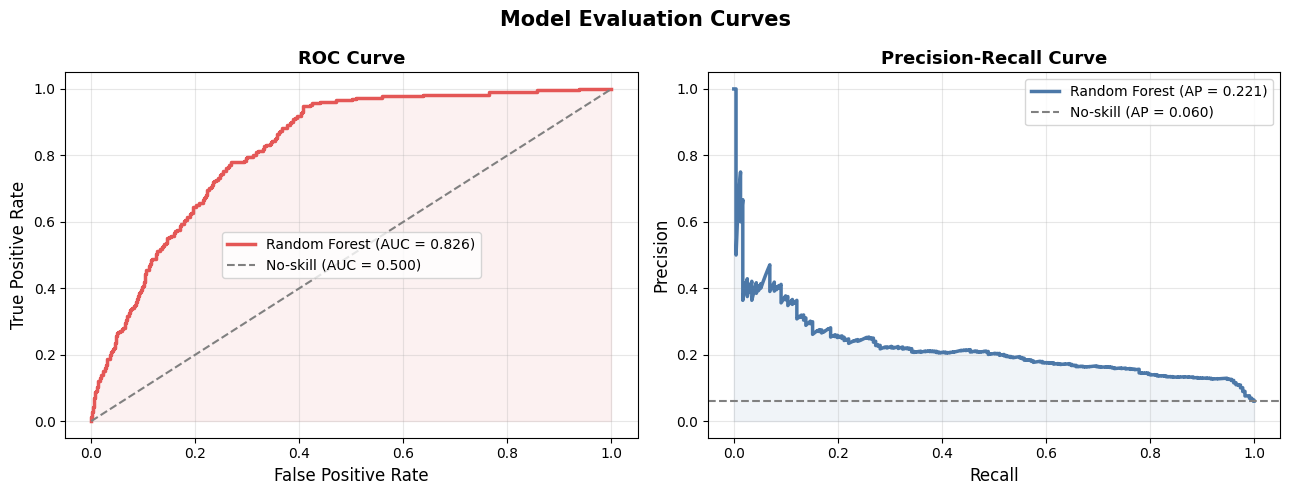

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation Curves', fontsize=15, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, color='#E45756', lw=2.5,
             label=f'Random Forest (AUC = {roc:.3f})')
axes[0].plot([0,1], [0,1], ls='--', color='grey', label='No-skill (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#E45756')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rec, prec, color='#4C78A8', lw=2.5,
             label=f'Random Forest (AP = {pr:.3f})')
axes[1].axhline(base, ls='--', color='grey', label=f'No-skill (AP = {base:.3f})')
axes[1].fill_between(rec, prec, alpha=0.08, color='#4C78A8')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Step 11 - Threshold selection**

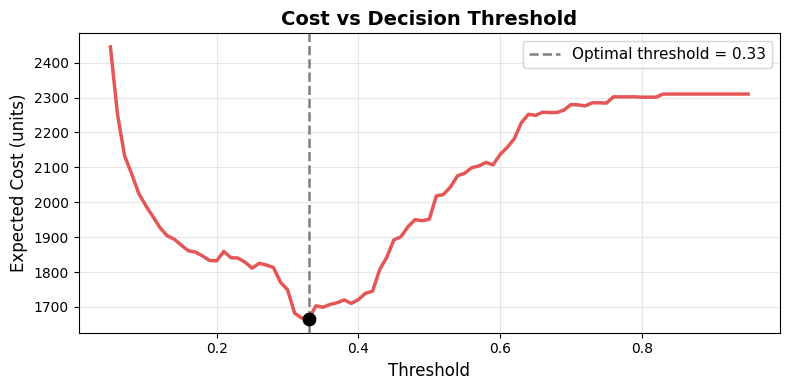

       THRESHOLD SELECTION (K=10)
  Assumption        : missing a fraud = 10x
                      cost of one investigation
  Optimal threshold : 0.33


In [88]:
K = 10
thresholds = np.linspace(0.05, 0.95, 91)
costs = []

for threshold in thresholds:
    tn, fp, fn, tp = confusion_matrix(y_test, (proba >= threshold).astype(int)).ravel()
    costs.append((tp + fp) + K * fn)

best_threshold = thresholds[np.argmin(costs)]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, costs, color='#E45756', lw=2.5)
plt.axvline(best_threshold, ls='--', color='grey', lw=1.8,
            label=f'Optimal threshold = {best_threshold:.2f}')
plt.scatter([best_threshold], [min(costs)], color='black', zorder=5, s=80)
plt.title('Cost vs Decision Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Expected Cost (units)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 45)
print("       THRESHOLD SELECTION (K=10)")
print("=" * 45)
print(f"  Assumption        : missing a fraud = {K}x")
print(f"                      cost of one investigation")
print(f"  Optimal threshold : {best_threshold:.2f}")
print("=" * 45)

**Step 12 - Confusion matrix**

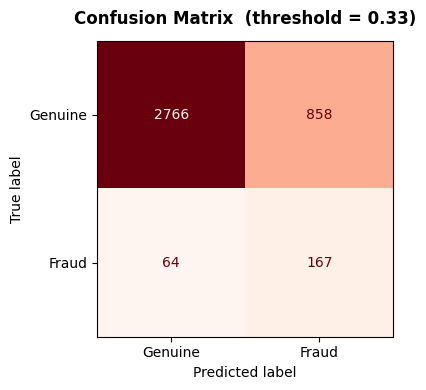


  Fraud correctly caught    : 167  (True Positives)
  Fraud missed              : 64  (False Negatives)
  False alarms              : 858  (False Positives)
  Genuine correctly cleared : 2766  (True Negatives)

  Recall on fraud           : 72.3% of all fraud caught


In [89]:
final_predictions = (proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, final_predictions)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Genuine', 'Fraud']).plot(
                       ax=ax, cmap='Reds', colorbar=False)
ax.set_title(f'Confusion Matrix  (threshold = {best_threshold:.2f})',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print(f"\n  Fraud correctly caught    : {tp}  (True Positives)")
print(f"  Fraud missed              : {fn}  (False Negatives)")
print(f"  False alarms              : {fp}  (False Positives)")
print(f"  Genuine correctly cleared : {tn}  (True Negatives)")
print(f"\n  Recall on fraud           : {tp/(tp+fn):.1%} of all fraud caught")


**Step 13 -  Feature importance**

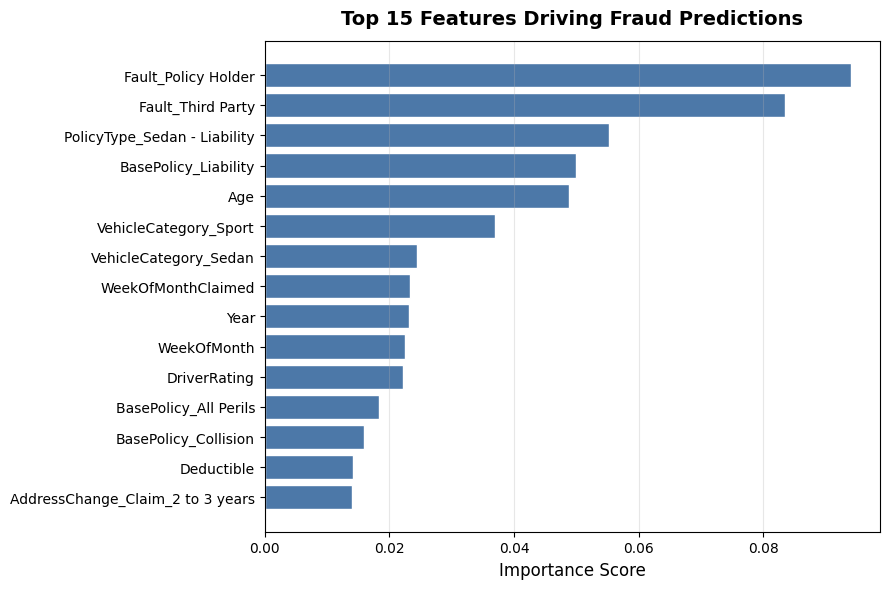


  TOP 5 FRAUD SIGNALS
  --------------------------------------
  1. Fault_Policy Holder                 0.0940
  2. Fault_Third Party                   0.0834
  3. PolicyType_Sedan - Liability        0.0553
  4. BasePolicy_Liability                0.0499
  5. Age                                 0.0488


In [90]:
model = best_model.named_steps['clf']
names = [n.split('__', 1)[-1] for n in best_model.named_steps['prep'].get_feature_names_out()]
importance_df = pd.DataFrame({'Feature': names,
                               'Importance': model.feature_importances_}
                             ).sort_values('Importance', ascending=False).head(15).reset_index(drop=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
         color='#4C78A8', edgecolor='white')
plt.title('Top 15 Features Driving Fraud Predictions',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Importance Score', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n  TOP 5 FRAUD SIGNALS")
print("  " + "-" * 38)
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<35} {row['Importance']:.4f}")

**Step 14 - Final Summary**

In [91]:
recall = tp / (tp + fn)

print("=" * 50)
print("            FINAL PROJECT SUMMARY")
print("=" * 50)
print(f"  Dataset          : fraud_oracle.csv")
print(f"  Total claims     : {len(y):,}")
print(f"  Fraud rate       : {y.mean():.1%}")
print("-" * 50)
print(f"  Best model       : {winner}")
print(f"  ROC-AUC          : {roc:.3f}")
print(f"  PR-AUC           : {pr:.3f}  (baseline: {base:.3f})")
print(f"  Improvement      : {pr/base:.1f}x better than random")
print("-" * 50)
print(f"  Threshold        : {best_threshold:.2f}  (cost ratio K={K})")
print(f"  Fraud caught     : {tp} of {tp+fn}  ({recall:.1%} recall)")
print(f"  Missed frauds    : {fn}")
print(f"  False alarms     : {fp}")
print("-" * 50)
print(f"  Top signal       : {importance_df.iloc[0]['Feature']}")
print("=" * 50)

            FINAL PROJECT SUMMARY
  Dataset          : fraud_oracle.csv
  Total claims     : 15,420
  Fraud rate       : 6.0%
--------------------------------------------------
  Best model       : Random Forest
  ROC-AUC          : 0.826
  PR-AUC           : 0.221  (baseline: 0.060)
  Improvement      : 3.7x better than random
--------------------------------------------------
  Threshold        : 0.33  (cost ratio K=10)
  Fraud caught     : 167 of 231  (72.3% recall)
  Missed frauds    : 64
  False alarms     : 858
--------------------------------------------------
  Top signal       : Fault_Policy Holder
